In [ ]:
# Script 2 Run FOOOF on averaged, interpolated non-log PSDs (TD and ASD) using a defined model parameters

In [1]:
## FOOOF Analysis Script - Light ONF
## Step 1: Setup and load data
from fooof import FOOOF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load meta data for NREM light on
df_metadata_nrem = pd.read_csv('C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/fooof_PAC_spindle/sleep/NREM_interpolated_PSDs/light_on/PFC_LFP/mouse_metadata.csv')

# Load meta data for REM Light ON
df_metadata_rem = pd.read_csv('C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/fooof_PAC_spindle/sleep/REM_interpolated_PSDs/light_on/PFC_LFP/mouse_metadata.csv')

# Load frequencies
freqs_clean = np.load('C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/fooof_PAC_spindle/sleep/REM_interpolated_PSDs/light_on/PFC_LFP/freqs_clean.npy')

print('Loaded metadata:')
print(df_metadata_nrem)
print(df_metadata_rem)
print(f'\nFrequency range: {freqs_clean[0]:.2f} - {freqs_clean[-1]:.2f} Hz')


C:\Users\cigde\AppData\Local\Temp\ipykernel_90176\1627747046.py:3: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


Loaded metadata:
   mouse_id genotype  n_bouts
0       WT3       WT       14
1       WT4       WT       13
2       WT5       WT        7
3       WT6       WT       11
4       WT7       WT       14
5       WT8       WT       15
6     Hom10    Q331K        8
7      Hom1    Q331K       11
8      Hom2    Q331K       11
9      Hom3    Q331K        9
10     Hom4    Q331K       13
11     Hom5    Q331K       16
12     Hom6    Q331K       10
13     Hom7    Q331K       13
   mouse_id genotype  n_bouts
0       WT3       WT       17
1       WT4       WT       10
2       WT5       WT       19
3       WT6       WT       10
4       WT7       WT       17
5       WT8       WT       14
6     HOM10    Q331K       12
7      HOM1    Q331K       12
8      HOM2    Q331K       12
9      HOM3    Q331K       16
10     HOM4    Q331K       13
11     HOM5    Q331K       14
12     HOM6    Q331K       11
13     HOM7    Q331K       15

Frequency range: 1.22 - 99.85 Hz


In [2]:
## Step 2a: Run FOOOF on each mouse's bouts (NREM and REM from separate state folders)
freq_range = [5, 45]
fooof_settings = {
    'peak_width_limits': [1, 12],
    'max_n_peaks': 8,
    'peak_threshold': 2,
    'min_peak_height': 0,
    'aperiodic_mode': 'fixed'
}

nrem_dir = 'C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/fooof_PAC_spindle/sleep/NREM_interpolated_PSDs/light_on/PFC_LFP'
rem_dir  = 'C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/fooof_PAC_spindle/sleep/REM_interpolated_PSDs/light_on/PFC_LFP'

all_results = []
for state, folder, meta in [('NREM', nrem_dir, df_metadata_nrem),
                            ('REM',  rem_dir,  df_metadata_rem)]:
    for idx, row in meta.iterrows():
        mouse_id = row['mouse_id']
        genotype = row['genotype']
        print(f'Processing {mouse_id} ({genotype}) {state}...')

        psd = np.load(os.path.join(folder, f'{mouse_id}_{state}_interp.npy'))  # (n_bouts, n_freqs)

        for bout in range(psd.shape[0]):
            fm = FOOOF(**fooof_settings)
            fm.fit(freqs_clean, psd[bout, :], freq_range=freq_range)
            all_results.append({
                'mouse_id': mouse_id,
                'genotype': genotype,
                'bout': bout,
                'state': state,
                'exponent': fm.aperiodic_params_[1],
                'offset': fm.aperiodic_params_[0],
                'r2': fm.r_squared_
            })

df_all = pd.DataFrame(all_results)
print(f'\n\nTotal fits: {len(df_all)}')
print('\nBreakdown by genotype and state:')
print(df_all.groupby(['genotype', 'state']).size())

save_dir = 'C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/fooof_PAC_spindle/sleep/final_fooof_june_26'
df_all.to_csv(os.path.join(save_dir, 'fooof_all_bouts_state.csv'), index=False)
print('\nSaved to fooof_all_bouts_state.csv')

Processing WT3 (WT) NREM...
Processing WT4 (WT) NREM...
Processing WT5 (WT) NREM...
Processing WT6 (WT) NREM...
Processing WT7 (WT) NREM...
Processing WT8 (WT) NREM...
Processing Hom10 (Q331K) NREM...
Processing Hom1 (Q331K) NREM...
Processing Hom2 (Q331K) NREM...
Processing Hom3 (Q331K) NREM...
Processing Hom4 (Q331K) NREM...
Processing Hom5 (Q331K) NREM...
Processing Hom6 (Q331K) NREM...
Processing Hom7 (Q331K) NREM...
Processing WT3 (WT) REM...
Processing WT4 (WT) REM...
Processing WT5 (WT) REM...
Processing WT6 (WT) REM...
Processing WT7 (WT) REM...
Processing WT8 (WT) REM...
Processing HOM10 (Q331K) REM...
Processing HOM1 (Q331K) REM...
Processing HOM2 (Q331K) REM...
Processing HOM3 (Q331K) REM...
Processing HOM4 (Q331K) REM...
Processing HOM5 (Q331K) REM...
Processing HOM6 (Q331K) REM...
Processing HOM7 (Q331K) REM...


Total fits: 357

Breakdown by genotype and state:
genotype  state
Q331K     NREM      91
          REM      105
WT        NREM      74
          REM       87
dtyp

In [4]:
# Step 2b: Filter by R² ≥ 0.90 and calculate per-mouse averages
print('\n' + '='*80)
print('FILTERING: Excluding transitions with R² < 0.90')
print('='*80)

# Show exclusion statistics
print(f'\nTotal transitions: {len(df_all)}')
print(f'R² < 0.90: {(df_all["r2"] < 0.90).sum()} excluded')
print(f'R² ≥ 0.90: {(df_all["r2"] >= 0.90).sum()} kept')

# Filter
df_filtered = df_all[df_all['r2'] >= 0.90].copy()
df_filtered['mouse_id'] = df_filtered['mouse_id'].str.upper()   # standardize Hom/HOM

# Calculate per-mouse averages
per_mouse_data = []

for mouse in df_filtered['mouse_id'].unique():
    mouse_data = df_filtered[df_filtered['mouse_id'] == mouse]
    genotype = mouse_data['genotype'].iloc[0]
    
    # NREM
    nrem_data = mouse_data[mouse_data['state'] == 'NREM']
    if len(nrem_data) > 0:
        nrem_mean_exp = nrem_data["exponent"].mean()
        nrem_mean_off = nrem_data["offset"].mean()
    else:
        nrem_mean_exp = np.nan
        nrem_mean_off = np.nan
    
    # REM
    rem_data = mouse_data[mouse_data['state'] == 'REM']
    if len(rem_data) > 0:
        rem_mean_exp = rem_data["exponent"].mean()
        rem_mean_off = rem_data["offset"].mean()
    else:
        rem_mean_exp = np.nan
        rem_mean_off = np.nan
    
    # Store
    per_mouse_data.append({
        'mouse_id': mouse,
        'genotype': genotype,
        'n_nrem': len(nrem_data),
        'n_rem': len(rem_data),
        'nrem_exponent': nrem_mean_exp,
        'nrem_offset': nrem_mean_off,
        'rem_exponent': rem_mean_exp,
        'rem_offset': rem_mean_off
    })

# Create dataframe
df_per_mouse = pd.DataFrame(per_mouse_data)

# Display
print('\n' + '='*80)
print('PER-MOUSE AVERAGES (AFTER R² FILTERING)')
print('='*80)
print(df_per_mouse.to_string(index=False))

# Save
df_per_mouse.to_csv(os.path.join(save_dir, 'fooof_per_mouse_averages.csv'), index=False)
print('\n✓ Saved to: fooof_per_mouse_averages.csv')

# Summary
print('\n' + '='*80)
print('FINAL SAMPLE SIZES:')
print('='*80)
print(f"WT: n={len(df_per_mouse[df_per_mouse['genotype']=='WT'])}")
print(f"Q331K: n={len(df_per_mouse[df_per_mouse['genotype']=='Q331K'])}")

# *** Convert WIDE to LONG format ***
df_long = []
for idx, row in df_per_mouse.iterrows():
    df_long.append({
        'mouse_id': row['mouse_id'],
        'genotype': row['genotype'],
        'state': 'NREM',
        'exponent': row['nrem_exponent'],
        'offset': row['nrem_offset']
    })
    df_long.append({
        'mouse_id': row['mouse_id'],
        'genotype': row['genotype'],
        'state': 'REM',
        'exponent': row['rem_exponent'],
        'offset': row['rem_offset']
    })

df_plot = pd.DataFrame(df_long)
print('\n✓ Data ready for plotting:')
print(df_plot)


FILTERING: Excluding transitions with R² < 0.90

Total transitions: 357
R² < 0.90: 8 excluded
R² ≥ 0.90: 349 kept

PER-MOUSE AVERAGES (AFTER R² FILTERING)
mouse_id genotype  n_nrem  n_rem  nrem_exponent  nrem_offset  rem_exponent  rem_offset
     WT3       WT      14     16       2.216269     4.911653      1.145362    3.285302
     WT4       WT      13      5       2.024605     4.705255      0.849599    3.011811
     WT5       WT       7     18       2.380735     4.786653      1.559799    3.572119
     WT6       WT      11     10       2.619882     5.147860      1.497049    3.457083
     WT7       WT      14     17       2.377742     4.734128      1.707802    3.674786
     WT8       WT      15     14       2.726801     4.840550      1.661266    3.191637
   HOM10    Q331K       8     12       2.182255     4.501311      1.650248    3.627748
    HOM1    Q331K      11     12       2.117992     4.550619      1.782135    3.964753
    HOM2    Q331K      11     12       2.024153     4.266687 

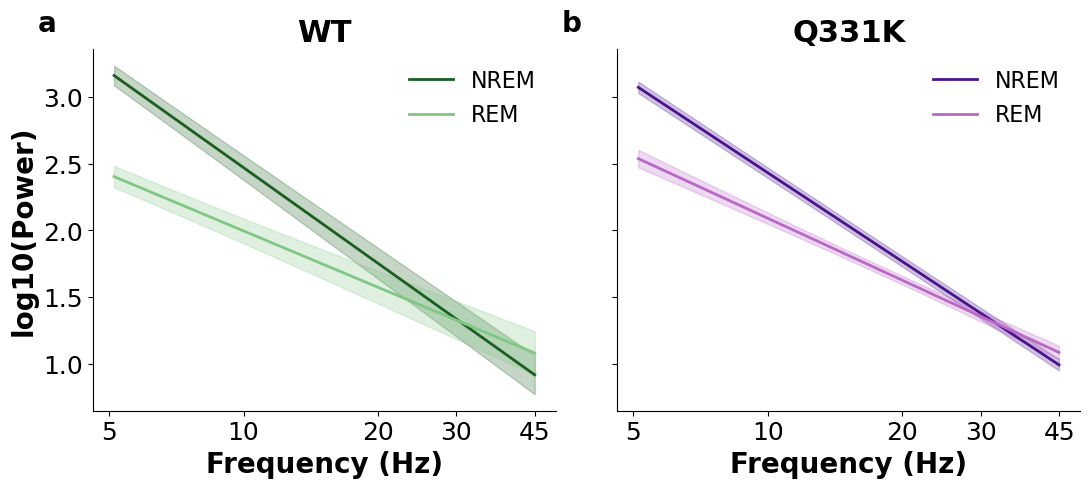

In [5]:
# Step 2c: Mean aperiodic slope +/- SEM, NREM vs REM, WT and Q331K in separate panels
shades = {
    'WT':    {'NREM': '#1b5e20', 'REM': '#81c784'},
    'Q331K': {'NREM': '#4a148c', 'REM': '#ba68c8'},
}
state_dirs  = {'NREM': nrem_dir, 'REM': rem_dir}
state_metas = {'NREM': df_metadata_nrem, 'REM': df_metadata_rem}

def mouse_ap_fits(genotype, state):
    fits = []
    meta = state_metas[state]
    for _, row in meta[meta['genotype'] == genotype].iterrows():
        fname_id = row['mouse_id']                      # original-case id for the file
        keep = df_filtered[(df_filtered['mouse_id'] == fname_id.upper()) &
                           (df_filtered['state'] == state)]['bout'].values
        if len(keep) == 0:
            continue
        psd = np.load(os.path.join(state_dirs[state], f'{fname_id}_{state}_interp.npy'))
        fm = FOOOF(**fooof_settings)
        fm.fit(freqs_clean, psd[keep, :].mean(axis=0), freq_range=freq_range)
        fits.append(fm._ap_fit)
    return np.array(fits), fm.freqs

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, geno in zip(axes, ['WT', 'Q331K']):
    for state in ['NREM', 'REM']:
        fits, f = mouse_ap_fits(geno, state)
        m   = fits.mean(axis=0)
        sem = fits.std(axis=0, ddof=1) / np.sqrt(fits.shape[0])
        ax.plot(f, m, color=shades[geno][state], lw=2, label=state)
        ax.fill_between(f, m - sem, m + sem, color=shades[geno][state], alpha=0.25)
    ax.set_title(geno, fontsize=22, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)', fontsize=20, fontweight='bold')
    ax.set_xscale('log')
    ax.set_xticks([5, 10, 20, 30, 45])
    ax.set_xticklabels([5, 10, 20, 30, 45])
    ax.tick_params(axis='both', labelsize=18)
    ax.minorticks_off()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, prop={'size': 16})
    ax.text(-0.12, 1.05, chr(ord('a') + list(axes).index(ax)),
            transform=ax.transAxes, fontsize=20, fontweight='bold')
axes[0].set_ylabel('log10(Power)', fontsize=20, fontweight='bold')
plt.tight_layout()
save_dir = 'C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/Sleep_paper/Figures/'
plt.savefig(os.path.join(save_dir, 'figure_8_a_b.png'), dpi=300)
plt.savefig(os.path.join(save_dir, 'figure_8_a_b.tiff'), dpi=300)

plt.show()

In [6]:
## STEP 3: Load FOOOF per-mouse averages (combined NREM+REM), then split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

combined = pd.read_csv('C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/fooof_PAC_spindle/sleep/final_fooof_june_26/fooof_per_mouse_averages.csv')

# Split into NREM and REM, renaming to plain 'exponent'/'offset' to match old code
nrem_on = combined[['mouse_id', 'genotype', 'nrem_exponent', 'nrem_offset']].rename(
    columns={'nrem_exponent': 'exponent', 'nrem_offset': 'offset'})
rem_on = combined[['mouse_id', 'genotype', 'rem_exponent', 'rem_offset']].rename(
    columns={'rem_exponent': 'exponent', 'rem_offset': 'offset'})

print("NREM Light ON:"); print(nrem_on)
print("\nREM Light ON:"); print(rem_on)

NREM Light ON:
   mouse_id genotype  exponent    offset
0       WT3       WT  2.216269  4.911653
1       WT4       WT  2.024605  4.705255
2       WT5       WT  2.380735  4.786653
3       WT6       WT  2.619882  5.147860
4       WT7       WT  2.377742  4.734128
5       WT8       WT  2.726801  4.840550
6     HOM10    Q331K  2.182255  4.501311
7      HOM1    Q331K  2.117992  4.550619
8      HOM2    Q331K  2.024153  4.266687
9      HOM3    Q331K  2.265966  4.757218
10     HOM4    Q331K  2.151815  4.581332
11     HOM5    Q331K  2.281805  4.650857
12     HOM6    Q331K  2.073113  4.667893
13     HOM7    Q331K  2.312237  4.690345

REM Light ON:
   mouse_id genotype  exponent    offset
0       WT3       WT  1.145362  3.285302
1       WT4       WT  0.849599  3.011811
2       WT5       WT  1.559799  3.572119
3       WT6       WT  1.497049  3.457083
4       WT7       WT  1.707802  3.674786
5       WT8       WT  1.661266  3.191637
6     HOM10    Q331K  1.650248  3.627748
7      HOM1    Q331K  1.782

In [7]:
# STEP 4: Organize data for NREM vs REM comparison plots
# Add a 'state' column to each dataframe
nrem_on['state'] = 'NREM'
rem_on['state'] = 'REM'

# Add a 'light' column
nrem_on['light'] = 'ON'
rem_on['light'] = 'ON'


# Combine Light ON data (NREM + REM)
light_on = pd.concat([nrem_on, rem_on], ignore_index=True)

# Check
print("Light ON combined:")
print(light_on[['mouse_id', 'genotype', 'state', 'exponent', 'offset']].head(10))

# Separate by genotype for plotting
light_on_wt = light_on[light_on['genotype'] == 'WT']
light_on_q331k = light_on[light_on['genotype'] == 'Q331K']

print(f"\nLight ON: {len(light_on_wt)} WT, {len(light_on_q331k)} Q331K")

Light ON combined:
  mouse_id genotype state  exponent    offset
0      WT3       WT  NREM  2.216269  4.911653
1      WT4       WT  NREM  2.024605  4.705255
2      WT5       WT  NREM  2.380735  4.786653
3      WT6       WT  NREM  2.619882  5.147860
4      WT7       WT  NREM  2.377742  4.734128
5      WT8       WT  NREM  2.726801  4.840550
6    HOM10    Q331K  NREM  2.182255  4.501311
7     HOM1    Q331K  NREM  2.117992  4.550619
8     HOM2    Q331K  NREM  2.024153  4.266687
9     HOM3    Q331K  NREM  2.265966  4.757218

Light ON: 12 WT, 16 Q331K


        Source           F         p_unc
0     genotype    0.246846  6.282814e-01
1        state  181.122321  1.334443e-08
2  Interaction    6.810564  2.281400e-02
exponent NREM WT: mean=2.391, sd=0.235, n=6
exponent NREM Q331K: mean=2.176, sd=0.097, n=8
exponent REM WT: mean=1.403, sd=0.307, n=6
exponent REM Q331K: mean=1.505, sd=0.225, n=8
        Source           F         p_unc
0     genotype    0.323148  5.802045e-01
1        state  219.691823  4.454542e-09
2  Interaction    6.863300  2.239358e-02
offset NREM WT: mean=4.854, sd=0.148, n=6
offset NREM Q331K: mean=4.583, sd=0.142, n=8
offset REM WT: mean=3.365, sd=0.227, n=6
offset REM Q331K: mean=3.536, sd=0.280, n=8


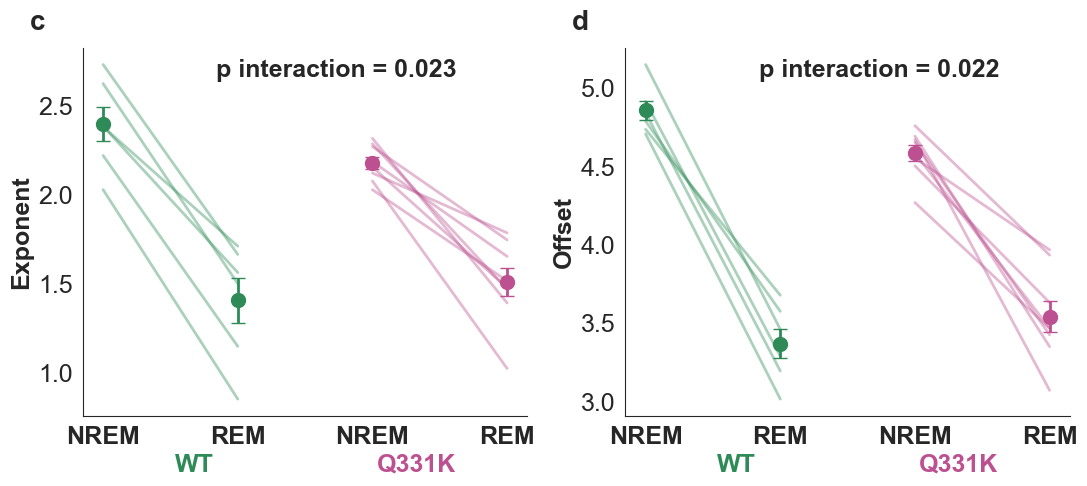

In [8]:
## Step 5: Paired lines: NREM vs REM state effect per animal - TDP-43 Q331K -  - figure 8c-d
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pingouin as pg
 
sns.set_style("white")
light_on['mouse_id'] = light_on['mouse_id'].str.upper()
 
colors = {'WT': '#2E8B57', 'Q331K': '#BC5090'}
 
def get_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'
 
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
 
for col, param, ylabel in [
    (0, 'exponent', 'Exponent'),
    (1, 'offset',   'Offset')
]:
    ax = axes[col]
    # Add panel labels
    ax.text(-0.12, 1.05, chr(ord('c') + col),
            transform=ax.transAxes, fontsize=20, fontweight='bold')
 
    for genotype in ['WT', 'Q331K']:
        gdf = light_on[light_on['genotype'] == genotype]
 
        # Individual animal lines
        for aid in gdf['mouse_id'].unique():
            nrem_val = gdf[(gdf['mouse_id'] == aid) & (gdf['state'] == 'NREM')][param].values
            rem_val  = gdf[(gdf['mouse_id'] == aid) & (gdf['state'] == 'REM')][param].values
            if len(nrem_val) and len(rem_val):
                ax.plot([0, 1] if genotype == 'WT' else [2, 3],
                        [nrem_val[0], rem_val[0]],
                        color=colors[genotype], alpha=0.4, linewidth=2)
 
        # Group means with SEM error bars
        for j, state in enumerate(['NREM', 'REM']):
            x = j if genotype == 'WT' else j + 2
            vals = gdf[gdf['state'] == state][param].values
            ax.plot(x, np.mean(vals), 'o', color=colors[genotype], markersize=10, zorder=4)
            ax.errorbar(x, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(len(vals)),
                        fmt='none', color=colors[genotype], linewidth=2, capsize=5)
 
    # Mixed ANOVA
    result = pg.mixed_anova(
        data=light_on,
        dv=param,
        between='genotype',
        within='state',
        subject='mouse_id'
    )
    p_inter = float(result[result['Source'] == 'Interaction']['p_unc'].iloc[0])
    print(result[['Source', 'F', 'p_unc']])
 
    # Descriptive stats
    for state in ['NREM', 'REM']:
        for genotype in ['WT', 'Q331K']:
            vals = light_on[(light_on['state'] == state) & (light_on['genotype'] == genotype)][param].values
            print(f"{param} {state} {genotype}: mean={np.mean(vals):.3f}, sd={np.std(vals):.3f}, n={len(vals)}")
 
    ax.text(0.3, 0.97, f"p interaction = {p_inter:.3f}",
            transform=ax.transAxes, fontsize=18, va='top', fontweight='bold')
 
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['NREM', 'REM', 'NREM', 'REM'], fontsize=18, fontweight='bold')
    ax.tick_params(axis='both', labelsize=18)
    ax.set_ylabel(ylabel, fontsize=18, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
 
    # Group labels below x-axis
    ax.annotate('WT', xytext=(0.25, -0.15), textcoords='axes fraction',
                xy=(0.25, 0), xycoords='axes fraction',
                ha='center', fontsize=18, color=colors['WT'], fontweight='bold')
    ax.annotate('Q331K', xytext=(0.75, -0.15), textcoords='axes fraction',
                xy=(0.75, 0), xycoords='axes fraction',
                ha='center', fontsize=18, color=colors['Q331K'], fontweight='bold')
 
#fig.suptitle('Aperiodic Parameters Across Sleep States', fontsize=20, fontweight='bold')
plt.tight_layout()

import os
save_dir = 'C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/Sleep_paper/Figures/'
plt.savefig(os.path.join(save_dir, 'figure_8_c_d.png'), dpi=300)
plt.savefig(os.path.join(save_dir, 'figure_8_c_d.tiff'), dpi=300)

plt.show()
 

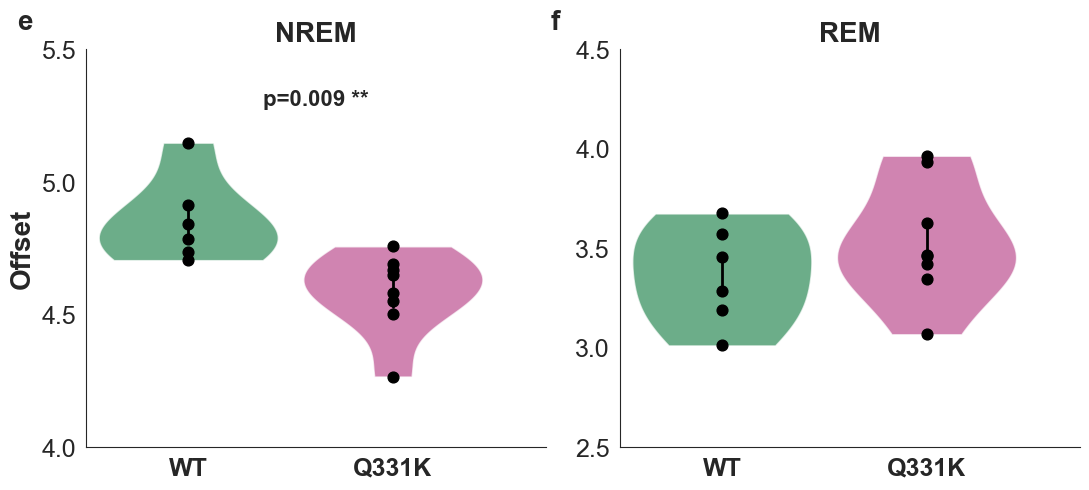

In [13]:
# Step 6: NREM and REM compare offset between groups  - figure 8e-f

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import ttest_ind

sns.set_style("white")
color_wt    = '#2E8B57'
color_q331k = '#BC5090'

def get_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

def plot_panel_offset(ax, wt_data, q331k_data, ylabel, title, show_legend, ylim, panel_letter, show_ylabel=True):
    parts = ax.violinplot([wt_data, q331k_data], positions=[0, 0.4], widths=0.35,
                          showmeans=False, showmedians=False, showextrema=False)
    parts['bodies'][0].set_facecolor(color_wt);    parts['bodies'][0].set_alpha(0.7)
    parts['bodies'][1].set_facecolor(color_q331k); parts['bodies'][1].set_alpha(0.7)

    for pos, data in zip([0, 0.4], [wt_data, q331k_data]):
        ax.scatter([pos]*len(data), data, color='black', s=60, marker='o', zorder=3)
        ax.plot([pos, pos], [data.mean()-data.sem(), data.mean()+data.sem()],
                color='black', linewidth=2, zorder=2)

    _, p = ttest_ind(wt_data, q331k_data, equal_var=False)
    if p < 0.05:
        ax.text(0.5, 0.90, f"p={p:.3f} {get_stars(p)}",
                transform=ax.transAxes, fontsize=16, va='top', ha='center', fontweight='bold')
    
    ax.text(-0.15, 1.05, panel_letter, transform=ax.transAxes, fontsize=20, fontweight='bold')

    ax.set_xticks([0, 0.4])
    ax.set_xticklabels(['WT', 'Q331K'], fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=18)
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.set_ylim(ylim)
    ax.set_xlim([-0.2, 0.7])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(title, fontsize=20, fontweight='bold')

# offset NREM and REM comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

plot_panel_offset(axes[0],
    light_on_wt[light_on_wt['state']=='NREM']['offset'],
    light_on_q331k[light_on_q331k['state']=='NREM']['offset'],
    'Offset', 'NREM', show_legend=False, ylim=[4, 5.5],
    panel_letter='e', show_ylabel=True)
plot_panel_offset(axes[1],
    light_on_wt[light_on_wt['state']=='REM']['offset'],
    light_on_q331k[light_on_q331k['state']=='REM']['offset'],
    'Offset', 'REM', show_legend=True, ylim=[2.5, 4.5],
    panel_letter='f', show_ylabel=False)

plt.tight_layout()

import os
save_dir = 'C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/Sleep_paper/Figures/'
plt.savefig(os.path.join(save_dir, 'figure_8_e_f.png'), dpi=300)
plt.savefig(os.path.join(save_dir, 'figure_8_e_f.tiff'), dpi=300)


plt.show()

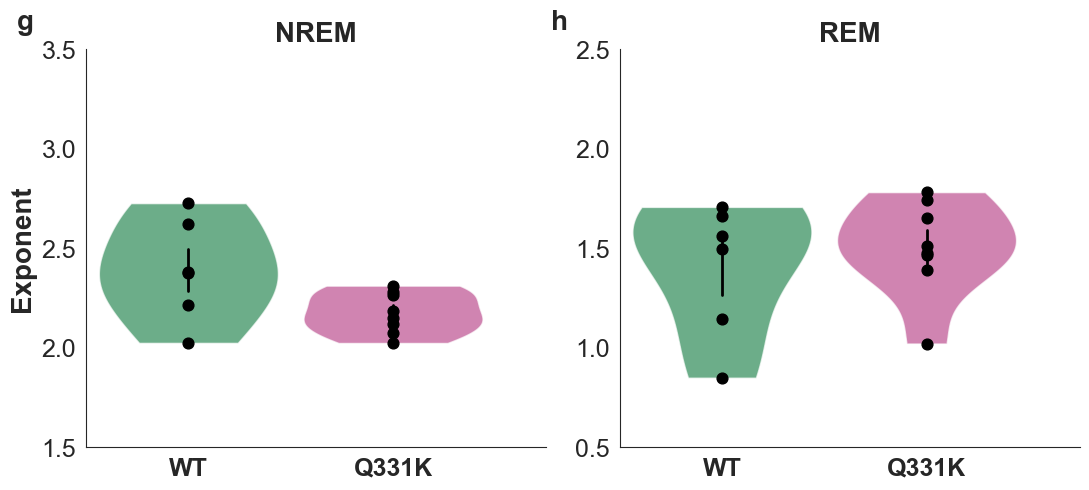

In [14]:
# Step 7: NREM and REM compare exponent between groups  - figure 8 g-h

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import ttest_ind

sns.set_style("white")
color_wt    = '#2E8B57'
color_q331k = '#BC5090'

def get_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

def plot_panel_exponent(ax, wt_data, q331k_data, ylabel, title, show_legend, ylim, panel_letter, show_ylabel=True):
    parts = ax.violinplot([wt_data, q331k_data], positions=[0, 0.4], widths=0.35,
                          showmeans=False, showmedians=False, showextrema=False)
    parts['bodies'][0].set_facecolor(color_wt);    parts['bodies'][0].set_alpha(0.7)
    parts['bodies'][1].set_facecolor(color_q331k); parts['bodies'][1].set_alpha(0.7)

    for pos, data in zip([0, 0.4], [wt_data, q331k_data]):
        ax.scatter([pos]*len(data), data, color='black', s=60, marker='o', zorder=3)
        ax.plot([pos, pos], [data.mean()-data.sem(), data.mean()+data.sem()],
                color='black', linewidth=2, zorder=2)

    _, p = ttest_ind(wt_data, q331k_data, equal_var=False)
    if p < 0.05:
        ax.text(0.5, 0.90, f"p={p:.3f} {get_stars(p)}",
                transform=ax.transAxes, fontsize=16, va='top', ha='center', fontweight='bold')

    ax.text(-0.15, 1.05, panel_letter, transform=ax.transAxes, fontsize=20, fontweight='bold')
    
    ax.set_xticks([0, 0.4])
    ax.set_xticklabels(['WT', 'Q331K'], fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=18)
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.set_ylim(ylim)
    ax.set_xlim([-0.2, 0.7])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(title, fontsize=20, fontweight='bold')


# Exponent NREM and REM comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

plot_panel_exponent(axes[0],
    light_on_wt[light_on_wt['state']=='NREM']['exponent'],
    light_on_q331k[light_on_q331k['state']=='NREM']['exponent'],
    'Exponent', 'NREM', show_legend=False, ylim=[1.5, 3.5],
     panel_letter='g', show_ylabel=True)

plot_panel_exponent(axes[1],
    light_on_wt[light_on_wt['state']=='REM']['exponent'],
    light_on_q331k[light_on_q331k['state']=='REM']['exponent'],
    'Exponent', 'REM', show_legend=True, ylim=[0.5, 2.5],
     panel_letter='h', show_ylabel=False)

plt.tight_layout()

import os
save_dir = 'C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/Sleep_paper/Figures/'
plt.savefig(os.path.join(save_dir, 'figure_8_g_h.png'), dpi=300)
plt.savefig(os.path.join(save_dir, 'figure_8_g_h.tiff'), dpi=300)

plt.show()

In [ ]:
  ## END ##